In [ ]:
#ResNet-50

In [1]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4
NUM_CLASSES = 4

TRAIN_DIR = r"D:\Download\likomia\data_split\train"
VAL_DIR   = r"D:\Download\likomia\data_split\val"
TEST_DIR  = r"D:\Download\likomia\data_split\test"


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])


In [4]:
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transform)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transform)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)


In [5]:
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)


for param in model.parameters():
    param.requires_grad = False


model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)


for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(DEVICE)

print(
    sum(p.requires_grad for p in model.parameters()),
    "trainable parameters (BASE ResNet50)"
)


2 trainable parameters (BASE ResNet50)


In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.3
)


In [7]:
best_val_acc = 0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):

    # -------- TRAIN --------
    model.train()
    train_loss, correct, total = 0, 0, 0

    for x, y in train_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    train_loss /= len(train_dl)
    train_acc = correct / total

    # -------- VALIDATION --------
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    val_loss /= len(val_dl)
    val_acc = correct / total

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )


Epoch [1/10] | Train Loss: 1.2374 | Train Acc: 0.5758 | Val Loss: 1.1171 | Val Acc: 0.7037
Epoch [2/10] | Train Loss: 1.0296 | Train Acc: 0.7719 | Val Loss: 0.9367 | Val Acc: 0.7695
Epoch [3/10] | Train Loss: 0.8705 | Train Acc: 0.8303 | Val Loss: 0.8580 | Val Acc: 0.8230
Epoch [4/10] | Train Loss: 0.7591 | Train Acc: 0.8734 | Val Loss: 0.7298 | Val Acc: 0.8621
Epoch [5/10] | Train Loss: 0.6709 | Train Acc: 0.8932 | Val Loss: 0.6464 | Val Acc: 0.8951
Epoch [6/10] | Train Loss: 0.6108 | Train Acc: 0.9059 | Val Loss: 0.5719 | Val Acc: 0.8992
Epoch [7/10] | Train Loss: 0.5315 | Train Acc: 0.9248 | Val Loss: 0.5154 | Val Acc: 0.9198
Epoch [8/10] | Train Loss: 0.5074 | Train Acc: 0.9262 | Val Loss: 0.4972 | Val Acc: 0.9177
Epoch [9/10] | Train Loss: 0.4605 | Train Acc: 0.9270 | Val Loss: 0.4265 | Val Acc: 0.9362
Epoch [10/10] | Train Loss: 0.4226 | Train Acc: 0.9415 | Val Loss: 0.3977 | Val Acc: 0.9444


In [8]:
model.load_state_dict(best_model_wts)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.to(DEVICE)
        out = model(x)
        preds = out.argmax(1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(y.numpy())

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted")
rec  = recall_score(y_true, y_pred, average="weighted")
f1   = f1_score(y_true, y_pred, average="weighted")

print("Base ResNet50 Results")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")


Base ResNet50 Results
Accuracy  : 0.9328
Precision : 0.9334
Recall    : 0.9328
F1-score  : 0.9300


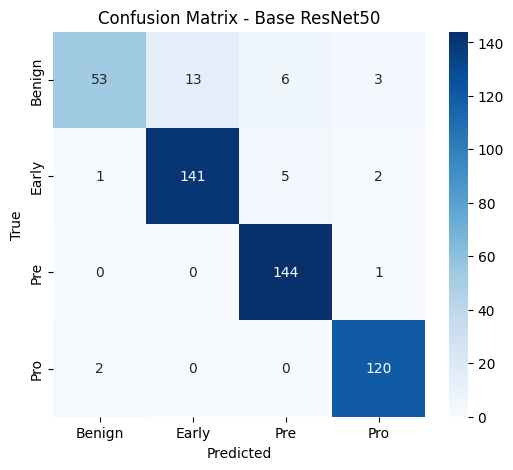

              precision    recall  f1-score   support

      Benign       0.95      0.71      0.81        75
       Early       0.92      0.95      0.93       149
         Pre       0.93      0.99      0.96       145
         Pro       0.95      0.98      0.97       122

    accuracy                           0.93       491
   macro avg       0.94      0.91      0.92       491
weighted avg       0.93      0.93      0.93       491



In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Base ResNet50")
plt.show()

print(classification_report(y_true, y_pred, target_names=train_ds.classes))


In [ ]:
#EfficientNet-B0

In [20]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt


In [21]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4
NUM_CLASSES = 4

TRAIN_DIR = r"D:\Download\likomia\data_split\train"
VAL_DIR   = r"D:\Download\likomia\data_split\val"
TEST_DIR  = r"D:\Download\likomia\data_split\test"


In [23]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])


In [24]:
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transform)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transform)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)


In [25]:
model = efficientnet_b0(
    weights=EfficientNet_B0_Weights.IMAGENET1K_V1
)


for param in model.parameters():
    param.requires_grad = False


model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    NUM_CLASSES
)


for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(DEVICE)

print(
    sum(p.requires_grad for p in model.parameters()),
    "trainable parameters (BASE EfficientNet-B0)"
)


2 trainable parameters (BASE EfficientNet-B0)


In [26]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.3
)


In [27]:
best_val_acc = 0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):

    # -------- TRAIN --------
    model.train()
    train_loss, correct, total = 0, 0, 0

    for x, y in train_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    train_loss /= len(train_dl)
    train_acc = correct / total

    # -------- VALIDATION --------
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    val_loss /= len(val_dl)
    val_acc = correct / total

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )


Epoch [1/10] | Train Loss: 1.2068 | Train Acc: 0.5701 | Val Loss: 1.0739 | Val Acc: 0.7654
Epoch [2/10] | Train Loss: 0.9524 | Train Acc: 0.7802 | Val Loss: 0.8905 | Val Acc: 0.8683
Epoch [3/10] | Train Loss: 0.7977 | Train Acc: 0.8523 | Val Loss: 0.7709 | Val Acc: 0.9012
Epoch [4/10] | Train Loss: 0.6822 | Train Acc: 0.8787 | Val Loss: 0.6826 | Val Acc: 0.9239
Epoch [5/10] | Train Loss: 0.5990 | Train Acc: 0.8976 | Val Loss: 0.5660 | Val Acc: 0.9424
Epoch [6/10] | Train Loss: 0.5284 | Train Acc: 0.9200 | Val Loss: 0.5412 | Val Acc: 0.9383
Epoch [7/10] | Train Loss: 0.4820 | Train Acc: 0.9248 | Val Loss: 0.4790 | Val Acc: 0.9465
Epoch [8/10] | Train Loss: 0.4368 | Train Acc: 0.9297 | Val Loss: 0.4135 | Val Acc: 0.9650
Epoch [9/10] | Train Loss: 0.4134 | Train Acc: 0.9301 | Val Loss: 0.4068 | Val Acc: 0.9671
Epoch [10/10] | Train Loss: 0.3883 | Train Acc: 0.9420 | Val Loss: 0.3789 | Val Acc: 0.9588


In [28]:
model.load_state_dict(best_model_wts)
model.eval()


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [29]:
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.to(DEVICE)
        out = model(x)
        preds = out.argmax(1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(y.numpy())

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted")
rec  = recall_score(y_true, y_pred, average="weighted")
f1   = f1_score(y_true, y_pred, average="weighted")

print("Base EfficientNet-B0 Results")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")


Base EfficientNet-B0 Results
Accuracy  : 0.9369
Precision : 0.9404
Recall    : 0.9369
F1-score  : 0.9368


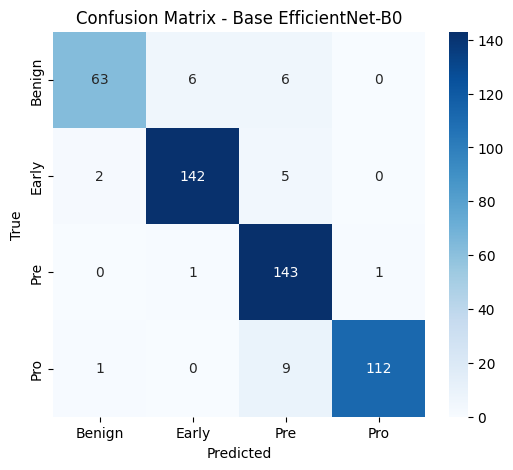

              precision    recall  f1-score   support

      Benign       0.95      0.84      0.89        75
       Early       0.95      0.95      0.95       149
         Pre       0.88      0.99      0.93       145
         Pro       0.99      0.92      0.95       122

    accuracy                           0.94       491
   macro avg       0.94      0.92      0.93       491
weighted avg       0.94      0.94      0.94       491



In [30]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_ds.classes,
    yticklabels=train_ds.classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Base EfficientNet-B0")
plt.show()

print(classification_report(y_true, y_pred, target_names=train_ds.classes))


In [ ]:
#VGG-16

In [31]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.models import vgg16, VGG16_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt


In [43]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5
LR = 1e-4
NUM_CLASSES = 4

TRAIN_DIR = r"D:\Download\likomia\data_split\train"
VAL_DIR   = r"D:\Download\likomia\data_split\val"
TEST_DIR  = r"D:\Download\likomia\data_split\test"


In [44]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])


In [45]:
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transform)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transform)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)


In [46]:
model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)


for param in model.features.parameters():
    param.requires_grad = False


model.classifier[6] = nn.Linear(
    model.classifier[6].in_features,
    NUM_CLASSES
)


for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(DEVICE)

print(
    sum(p.requires_grad for p in model.parameters()),
    "trainable parameters (BASE VGG-16)"
)


6 trainable parameters (BASE VGG-16)


In [47]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.3
)


In [ ]:
best_val_acc = 0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):

    # -------- TRAIN --------
    model.train()
    train_loss, correct, total = 0, 0, 0

    for x, y in train_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    train_loss /= len(train_dl)
    train_acc = correct / total

    # -------- VALIDATION --------
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    val_loss /= len(val_dl)
    val_acc = correct / total

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )


In [41]:
model.load_state_dict(best_model_wts)
model.eval()


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [42]:
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.to(DEVICE)
        out = model(x)
        preds = out.argmax(1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(y.numpy())

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted")
rec  = recall_score(y_true, y_pred, average="weighted")
f1   = f1_score(y_true, y_pred, average="weighted")

print("Base VGG-16 Results")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")


Base VGG-16 Results
Accuracy  : 0.9817
Precision : 0.9821
Recall    : 0.9817
F1-score  : 0.9818


In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_ds.classes,
    yticklabels=train_ds.classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Base VGG-16")
plt.show()

print(classification_report(y_true, y_pred, target_names=train_ds.classes))
